# Session 4: Unit Testing and Continuous Integration

**Workshop:** Undergraduate Research Computing Bootcamp

> Open this notebook in Google Colab and run each code cell in order.

In the previous session, you learned how Git saves project history and how GitHub helps people collaborate. In this session, we add the next layer: **how to check that code still works after someone changes it.**

## Learning objectives

By the end of this session, you should be able to:

1. Explain why research code needs tests.
2. Describe what a **unit test** checks.
3. Write a simple test using `assert`.
4. Run tests with `pytest`.
5. Explain what **continuous integration (CI)** does on GitHub.
6. Connect GitHub pull requests to automatic test checks.

We will move slowly. Each section introduces only one new concept.

## Big picture: where this session fits

Last session:

```text
edit code → git add → git commit → push to GitHub → pull request
```

This session adds one important question:

```text
Did the code still work after the change?
```

That is the purpose of testing and continuous integration.

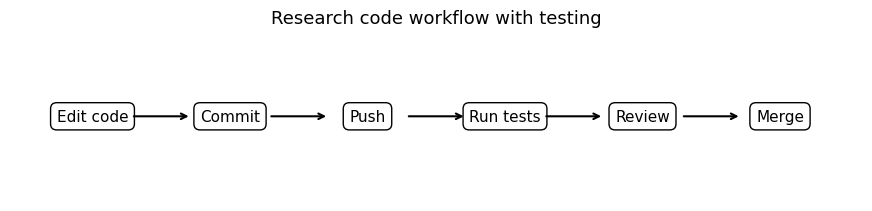

In [1]:
# Visualization 1: GitHub workflow with tests added

import matplotlib.pyplot as plt

def draw_workflow(labels, title):
    fig, ax = plt.subplots(figsize=(11, 2.2))
    ax.axis("off")

    for i, label in enumerate(labels):
        ax.text(
            i, 0.5, label,
            ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.4", edgecolor="black", facecolor="white"),
            fontsize=11
        )
        if i < len(labels) - 1:
            ax.annotate(
                "", xy=(i + 0.72, 0.5), xytext=(i + 0.28, 0.5),
                arrowprops=dict(arrowstyle="->", lw=1.5)
            )

    ax.set_xlim(-0.6, len(labels) - 0.4)
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=13)
    plt.show()

draw_workflow(
    ["Edit code", "Commit", "Push", "Run tests", "Review", "Merge"],
    "Research code workflow with testing"
)

## Concept 1: Why do we test research code?

Research code often starts small:

```text
one function → one script → one notebook → one project → one shared repository
```

At first, it is easy to check results manually. But as the code grows, manual checking becomes unreliable.

A test is a small automatic check that asks:

> Does this part of the code still do what we expect?

### Example research function

Suppose we are analyzing a simple cardiovascular quantity:

```text
resistance = pressure drop / flow rate
```

This is a small function. Small functions are good places to start testing.

In [2]:
def pressure_drop_resistance(pressure_drop, flow_rate):
    """Calculate resistance from pressure drop and flow rate."""
    if flow_rate <= 0:
        raise ValueError("flow_rate must be positive")
    return pressure_drop / flow_rate

pressure_drop_resistance(10, 2)

5.0

## Concept 2: A unit test checks one small unit of code

A **unit** is usually one function, method, or small piece of logic.

A **unit test** checks whether that small unit behaves as expected.

For this function, we know:

```text
pressure_drop_resistance(10, 2) should return 5
```

That expected result can become a test.

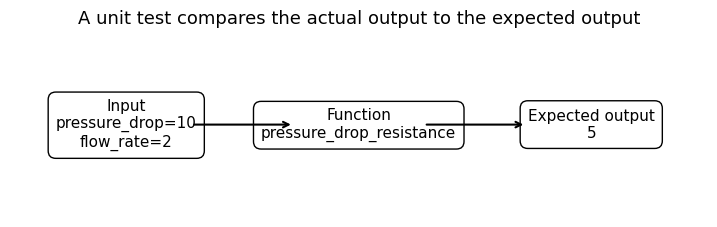

In [3]:
# Visualization 2: A unit test checks one function

fig, ax = plt.subplots(figsize=(9, 2.4))
ax.axis("off")

items = [
    ("Input\npressure_drop=10\nflow_rate=2", 0),
    ("Function\npressure_drop_resistance", 1),
    ("Expected output\n5", 2)
]

for text, x in items:
    ax.text(
        x, 0.5, text,
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.5", edgecolor="black", facecolor="white"),
        fontsize=11
    )

for x in [0, 1]:
    ax.annotate("", xy=(x + 0.72, 0.5), xytext=(x + 0.28, 0.5),
                arrowprops=dict(arrowstyle="->", lw=1.5))

ax.set_xlim(-0.5, 2.5)
ax.set_ylim(0, 1)
ax.set_title("A unit test compares the actual output to the expected output", fontsize=13)
plt.show()

## Concept 3: `assert` means “this should be true”

Python has a built-in command called `assert`.

If the statement is true, nothing happens. If the statement is false, Python raises an error.

That error is useful because it tells us something is wrong.

In [4]:
# This should pass silently.
assert pressure_drop_resistance(10, 2) == 5

print("The assertion passed.")

The assertion passed.


In [5]:
# This cell intentionally catches a failed assertion so the notebook can keep running.

try:
    assert pressure_drop_resistance(10, 2) == 99
except AssertionError:
    print("The assertion failed because the expected value was wrong.")

The assertion failed because the expected value was wrong.


## Pause and interpret

In your own words:

```text
assert pressure_drop_resistance(10, 2) == 5
```

means:

> I expect this function to return 5 when the inputs are 10 and 2.

This is the core idea of unit testing.

## Concept 4: A test file stores tests separately from the main code

In real projects, we usually separate:

```text
analysis_utils.py          # code we want to use
test_analysis_utils.py     # tests that check the code
```

This makes it easier for GitHub and CI tools to find and run the tests automatically.

In [6]:
%%writefile analysis_utils.py
def pressure_drop_resistance(pressure_drop, flow_rate):
    """Calculate resistance from pressure drop and flow rate."""
    if flow_rate <= 0:
        raise ValueError("flow_rate must be positive")
    return pressure_drop / flow_rate

Writing analysis_utils.py


In [7]:
%%writefile test_analysis_utils.py
from analysis_utils import pressure_drop_resistance

def test_pressure_drop_resistance_basic_case():
    assert pressure_drop_resistance(10, 2) == 5

Writing test_analysis_utils.py


## Concept 5: `pytest` finds and runs test functions

`pytest` is a common Python testing tool.

By convention, `pytest` looks for:

```text
files named test_*.py
functions named test_*
```

Our file is named:

```text
test_analysis_utils.py
```

Our test function is named:

```text
test_pressure_drop_resistance_basic_case
```

In [8]:
# Install pytest if needed, then run the test file.
# In many Colab environments, pytest is already installed.

try:
    import pytest
    print("pytest is already installed.")
except ImportError:
    %pip -q install pytest
    print("pytest was installed.")

!pytest -q test_analysis_utils.py

pytest is already installed.
.                                                                        [100%]
1 passed in 0.00s


## Pause and interpret the output

If you see something like:

```text
1 passed
```

that means:

```text
pytest found one test, ran it, and the test passed.
```

Passing tests do not prove that the whole project is perfect. They only show that the cases we tested behaved as expected.

## Concept 6: Good tests check normal cases and edge cases

A **normal case** is a typical input.

Example:

```text
pressure_drop = 10
flow_rate = 2
```

An **edge case** is an input that might cause problems.

Example:

```text
flow_rate = 0
```

A flow rate of zero would cause division by zero, so our function should reject it clearly.

In [9]:
%%writefile test_analysis_utils.py
import pytest
from analysis_utils import pressure_drop_resistance

def test_pressure_drop_resistance_basic_case():
    assert pressure_drop_resistance(10, 2) == 5

def test_pressure_drop_resistance_rejects_zero_flow():
    with pytest.raises(ValueError):
        pressure_drop_resistance(10, 0)

Overwriting test_analysis_utils.py


In [10]:
!pytest -q test_analysis_utils.py

..                                                                       [100%]
2 passed in 0.00s


## Concept 7: Test names should explain the expected behavior

These names are better than `test_1` and `test_2`:

```python
test_pressure_drop_resistance_basic_case
test_pressure_drop_resistance_rejects_zero_flow
```

Why?

Because the test name explains what the code is supposed to do.

Good test names become documentation for future students, collaborators, and your future self.

## Concept 8: Tests help catch accidental changes

Now we will intentionally break the function.

We will change:

```python
return pressure_drop / flow_rate
```

to:

```python
return pressure_drop * flow_rate
```

This is wrong for our formula. The test should catch the mistake.

In [11]:
%%writefile analysis_utils.py
def pressure_drop_resistance(pressure_drop, flow_rate):
    """Calculate resistance from pressure drop and flow rate."""
    if flow_rate <= 0:
        raise ValueError("flow_rate must be positive")

    # Intentional bug for teaching:
    return pressure_drop * flow_rate

Overwriting analysis_utils.py


In [12]:
# This should fail.
# A failing test is not bad. It is useful feedback.

!pytest -q test_analysis_utils.py

F.                                                                       [100%]
=================================== FAILURES ===================================
___________________ test_pressure_drop_resistance_basic_case ___________________

    def test_pressure_drop_resistance_basic_case():
>       assert pressure_drop_resistance(10, 2) == 5
E       assert 20 == 5
E        +  where 20 = pressure_drop_resistance(10, 2)

test_analysis_utils.py:5: AssertionError
=========================== short test summary info ============================
FAILED test_analysis_utils.py::test_pressure_drop_resistance_basic_case - assert 20 == 5
1 failed, 1 passed in 0.02s


## Pause and interpret the failure

A failing test usually tells you:

1. Which test failed.
2. What value was expected.
3. What value was actually produced.
4. Where the problem happened.

This is one reason tests are helpful: they turn silent mistakes into visible feedback.

## Fix the function

Now we restore the correct formula.

In [13]:
%%writefile analysis_utils.py
def pressure_drop_resistance(pressure_drop, flow_rate):
    """Calculate resistance from pressure drop and flow rate."""
    if flow_rate <= 0:
        raise ValueError("flow_rate must be positive")
    return pressure_drop / flow_rate

Overwriting analysis_utils.py


In [14]:
!pytest -q test_analysis_utils.py

..                                                                       [100%]
2 passed in 0.00s


## Your turn 1: Add one more test

Add a new test for this case:

```text
pressure_drop_resistance(9, 3) should return 3
```

Then run `pytest` again.

Hint:

```python
def test_pressure_drop_resistance_another_case():
    assert pressure_drop_resistance(9, 3) == 3
```

In [15]:
# Your turn:
# 1. Edit test_analysis_utils.py.
# 2. Add the new test.
# 3. Run pytest again.

# You can use %%writefile again, or edit the file manually in Colab's file browser.

## Concept 9: What is continuous integration?

**Continuous integration**, often called **CI**, means:

> Every time code is pushed or a pull request is opened, an online service automatically runs checks.

For this workshop, the most important CI check is:

```text
Run the tests automatically.
```

In GitHub, CI is commonly implemented using **GitHub Actions**.

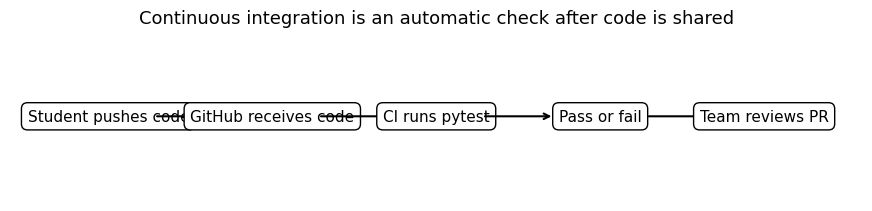

In [16]:
# Visualization 3: CI as an automatic reviewer

draw_workflow(
    ["Student pushes code", "GitHub receives code", "CI runs pytest", "Pass or fail", "Team reviews PR"],
    "Continuous integration is an automatic check after code is shared"
)

## Concept 10: CI protects the main branch

A common research workflow is:

```text
main branch = stable code
feature branch = new work
pull request = request to merge new work into main
CI = automatic test check before merging
```

The goal is not to make students afraid of changing code. The goal is to make changes safer.

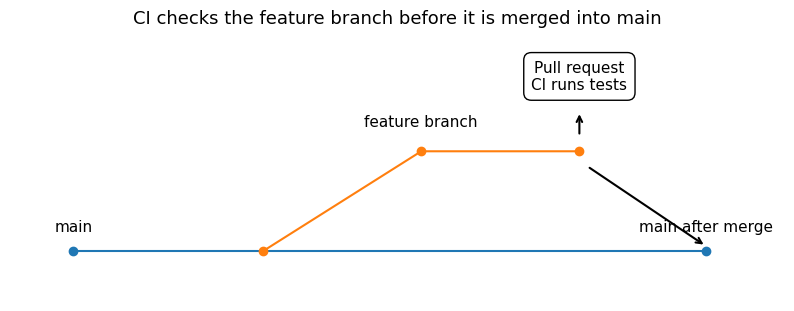

In [17]:
# Visualization 4: Branch + pull request + CI

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis("off")

# Draw main branch
ax.plot([0, 4], [0.7, 0.7], marker="o")
ax.text(0, 0.9, "main", ha="center", fontsize=11)
ax.text(4, 0.9, "main after merge", ha="center", fontsize=11)

# Draw feature branch
ax.plot([1.2, 2.2, 3.2], [0.7, 1.7, 1.7], marker="o")
ax.text(2.2, 1.95, "feature branch", ha="center", fontsize=11)

# Pull request and CI box
ax.text(
    3.2, 2.45,
    "Pull request\nCI runs tests",
    ha="center", va="center",
    bbox=dict(boxstyle="round,pad=0.5", edgecolor="black", facecolor="white"),
    fontsize=11
)

ax.annotate("", xy=(3.2, 2.1), xytext=(3.2, 1.85), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.annotate("", xy=(4.0, 0.75), xytext=(3.25, 1.55), arrowprops=dict(arrowstyle="->", lw=1.5))

ax.set_xlim(-0.4, 4.5)
ax.set_ylim(0.2, 2.9)
ax.set_title("CI checks the feature branch before it is merged into main", fontsize=13)
plt.show()

## Concept 11: A GitHub Actions workflow is a small YAML file

To tell GitHub to run tests automatically, we add a workflow file:

```text
.github/workflows/tests.yml
```

This file says:

```text
When someone pushes code or opens a pull request:
    set up Python
    install pytest
    run pytest
```

In [18]:
# Create the GitHub Actions folder structure inside this Colab workspace.

!mkdir -p .github/workflows

In [19]:
%%writefile .github/workflows/tests.yml
name: Tests

on:
  push:
  pull_request:

jobs:
  test:
    runs-on: ubuntu-latest

    steps:
      - name: Check out repository
        uses: actions/checkout@v4

      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.11"

      - name: Install test dependency
        run: pip install pytest

      - name: Run tests
        run: pytest -q

Writing .github/workflows/tests.yml


In [20]:
!cat .github/workflows/tests.yml

name: Tests

on:
  push:
  pull_request:

jobs:
  test:
    runs-on: ubuntu-latest

    steps:
      - name: Check out repository
        uses: actions/checkout@v4

      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.11"

      - name: Install test dependency
        run: pip install pytest

      - name: Run tests
        run: pytest -q


## Pause and interpret the workflow

This part tells GitHub when to run CI:

```yaml
on:
  push:
  pull_request:
```

This part tells GitHub what command to run:

```yaml
run: pytest -q
```

So the GitHub version of this notebook workflow is:

```text
push code → GitHub Actions starts → pytest runs → pass/fail result appears on GitHub
```

## Concept 12: Why CI matters for research teams

CI is useful because it makes quality checks:

```text
automatic
repeatable
visible to the whole team
```

This matters in research because code changes can affect results, figures, tables, and conclusions.

A simple test suite can help answer:

> Did this change break something we already trusted?

## Your turn 2: Break it, fix it, explain it

Work with a partner or small group.

1. Break the function again by changing `/` to `*`.
2. Run `pytest`.
3. Read the error message.
4. Fix the function.
5. Run `pytest` again.
6. Explain what happened in one sentence.

Example explanation:

```text
The test failed because the function returned 20 instead of 5, which showed that the formula was accidentally changed.
```

## Concept 13: How this connects to the next research repository session

When you clone a real research repository, look for:

```text
tests/
test_*.py
.github/workflows/
README.md
requirements.txt
pyproject.toml
```

These files tell you:

1. How the project is tested.
2. What packages it needs.
3. Whether tests run automatically on GitHub.
4. How contributors are expected to check their work.

In [21]:
# Quick file check in this Colab workspace

!find . -maxdepth 3 -type f | sort

./.github/workflows/tests.yml
./.pytest_cache/.gitignore
./.pytest_cache/CACHEDIR.TAG
./.pytest_cache/README.md
./01_introduction_to_colab_and_research_computing.ipynb
./02_python_foundations_for_research.ipynb
./03_git_and_github_fundamentals.ipynb
./04_unit_testing_and_continuous_integration.ipynb
./05_running_a_real_research_repository.ipynb
./06_scientific_visualization_and_data.ipynb
./07_contributing_to_research_code.ipynb
./README.md
./__pycache__/analysis_utils.cpython-313.pyc
./__pycache__/test_analysis_utils.cpython-313-pytest-8.4.2.pyc
./analysis_utils.py
./test_analysis_utils.py


## Minimal cheat sheet

```bash
# Run one test file
pytest -q test_analysis_utils.py

# Run all tests in the current project
pytest -q

# Common Git + testing workflow
git status
git add analysis_utils.py test_analysis_utils.py .github/workflows/tests.yml
git commit -m "Add unit tests and CI workflow"
git push
```

Important idea:

```text
Commit the code AND the tests.
```

## Wrap-up

You should now be able to explain:

1. A unit test checks one small piece of code.
2. `assert` compares expected behavior to actual behavior.
3. `pytest` finds and runs test files.
4. A failing test is useful feedback.
5. CI runs tests automatically after code is pushed or a pull request is opened.
6. CI helps protect the main branch of a shared research repository.

Before the next session, make sure you can explain this workflow:

```text
student changes code → student adds tests → student pushes branch → CI runs tests → pull request is reviewed → code is merged
```

## Optional instructor note

This session intentionally uses one small function throughout the notebook. The goal is not to teach advanced testing. The goal is to make the testing workflow feel concrete:

```text
expected result → test → pytest → pass/fail → CI
```

More advanced topics such as fixtures, test coverage, mocking, package structure, and matrix builds can be introduced later after students are comfortable with the basic workflow.